<!-- DEA Notebook Header -->
<div style="font-family:'Segoe UI',Roboto,sans-serif; line-height:1.6; color:CanvasText; padding:32px;">

<img src="https://raw.githubusercontent.com/GeoscienceAustralia/dea-notebooks/stable/Supplementary_data/dea_logo_wide.jpg" alt="DEA Notebooks logo" style="width:86.5%;">

<h1>Working with time in Xarray</h1>

<p>
🔎 Visit <a href="https://knowledge.dea.ga.gov.au">DEA's Knowledge Hub</a> for detailed technical information about the datasets and concepts used in this notebook.
</p>

<p>
<span style="display:inline-block; font-size:12px; background:rgba(59,130,246,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">🟢 Beginner</span>
<span style="display:inline-block; font-size:12px; background:rgba(16,185,129,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">⚡ Time to complete: ~10 mins</span>
<span style="display:inline-block; font-size:12px; background:rgba(107,114,128,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">🗓️ Updated: 2025-12</span>
</p>

<!-- Products - REQUIRED -->
<div style="margin-bottom:12px; padding:12px; background:rgba(59,130,246,0.08); border:1px solid rgb(59,130,246); border-radius:8px; max-width:85%;">
<b>📦 Products used</b><br>
<a href="https://knowledge.dea.ga.gov.au/data/category/landsat-8-analysis-ready-data/">ga_ls8c_ard_3</a>,
</div>

<!-- How to run - REQUIRED -->
<div style="margin-bottom:12px; padding:12px; background:rgba(16,185,129,0.1); border:1px solid rgb(16,185,129); border-radius:8px; max-width:85%;">
<b>🚀 How you can run this notebook</b><br>

- <b>DEA Sandbox:</b> Eligible users can sign up for the <a href="https://knowledge.dea.ga.gov.au/guides/setup/Sandbox/sandbox/">DEA Sandbox</a> that provides free compute and a managed Python environment.

- <b>Personal computer:</b> This notebook loads DEA data using <code>odc-stac</code>. Data streams via the internet, so can be run locally after installing the required <a href="https://pypi.org/project/dea-tools/">DEA Tools</a> Python package, e.g. <code>pip install dea-tools[notebooks]</code>.

- <b>Run this notebook online:</b> Click on the badge below to launch a GitHub Codespaces instance to run the notebook from your browser. See this <a href="">wiki page</a> for more information.

  <a href="https://codespaces.new/GeoscienceAustralia/dea-notebooks/tree/template?quickstart=1" target="_blank">
    <img src="https://img.shields.io/badge/Codespaces-Open-blue?logo=github" alt="Open in GitHub Codespaces" style="height:25px;">
  </a>
</div>

</div>

## Description
The `xarray` Python package provides many useful techniques for dealing with time series data that can be applied to Digital Earth Australia data. 
This notebook demonstrates how to use `xarray` techniques to:

1. Select different time periods of data (e.g. year, month, day) from an `xarray.Dataset`
2. Using datetime accessors to extract additional information from a dataset's `time` dimension
3. Summarising time series data for different time periods using `.groupby()` and `.resample()`
4. Interpolating time series data to estimate landscape conditions at a specific date that the satellite did not observe

For additional information about the techniques demonstrated below, refer to the `xarray` [Time series data guide](http://xarray.pydata.org/en/stable/time-series.html). 

***

## Setup

### Load packages
Import Python packages that are used for the analysis.

In [106]:
import odc.stac
import pystac_client
from odc.geo import BoundingBox
import matplotlib.pyplot as plt

### Connect to DEA's STAC API

In [107]:
# Configure data access
odc.stac.configure_s3_access(cloud_defaults=True, aws_unsigned=True)

# Connect to DEA STAC API
catalog = pystac_client.Client.open("https://explorer.dea.ga.gov.au/stac")

## Analysis

First, we load in a two years of Landsat 8 data, and apply a simple cloud mask. To learn more about masking data, see the [masking data](./Masking_data.ipynb) notebook.

In [116]:
# Set a loading date - Landsat geomedians are annual products
start_date = "2015-01-01"
end_date = "2016-12-31"

# Set lat and lon range for study area
# lat_range = (-32.22, -32.32)
# lon_range = (142.41, 142.51)


lat = -30.56351
lon = 143.76091
lat_buffer = 0.03
lon_buffer = 0.035

# Set product ID as the STAC "collection"
collections = ["ga_ls8c_ard_3"]

### Create and plot the bounding box region-of-interest

In [117]:
bbox = BoundingBox(
    left=lon - lon_buffer,
    bottom=lat - lat_buffer,
    right=lon + lon_buffer,
    top=lat + lat_buffer,
)

# bbox = BoundingBox(
#     left=min(lon_range),
#     bottom=min(lat_range),
#     right=max(lon_range),
#     top=max(lat_range),
#     crs="EPSG:4326",
# )

bbox.explore()

### Searching for STAC data using `pystac_client`

We can use the `pystac_client` Python package to search for STAC items that match our query:

In [118]:
# Search the STAC catalog for all items matching the query
query = catalog.search(
    bbox=bbox,
    collections=collections,
    datetime=f"{start_date}/{end_date}",
)

# Convert to a list
items = list(query.items())
print(f"Found: {len(items):d} STAC items")

Found: 90 STAC items


In [119]:
ds = odc.stac.load(
    items,
    bands=['nbart_nir', 'oa_fmask'],
    crs="EPSG:3577",
    resolution=30,
    bbox=bbox,
    groupby="solar_day"
)

ds = ds.where(ds.oa_fmask.isin([1, 4, 5]))

ds


<xarray.Dataset> Size: 43MB
Dimensions:      (time: 90, y: 244, x: 242)
Coordinates:
  * y            (y) float64 2kB -3.374e+06 -3.374e+06 ... -3.381e+06 -3.381e+06
  * x            (x) float64 2kB 1.111e+06 1.111e+06 ... 1.118e+06 1.118e+06
    spatial_ref  int32 4B 3577
  * time         (time) datetime64[ns] 720B 2015-01-06T00:20:03.050919 ... 20...
Data variables:
    nbart_nir    (time, y, x) float32 21MB 2.844e+03 2.895e+03 ... nan nan
    oa_fmask     (time, y, x) float32 21MB 1.0 1.0 1.0 1.0 ... 1.0 nan nan nan

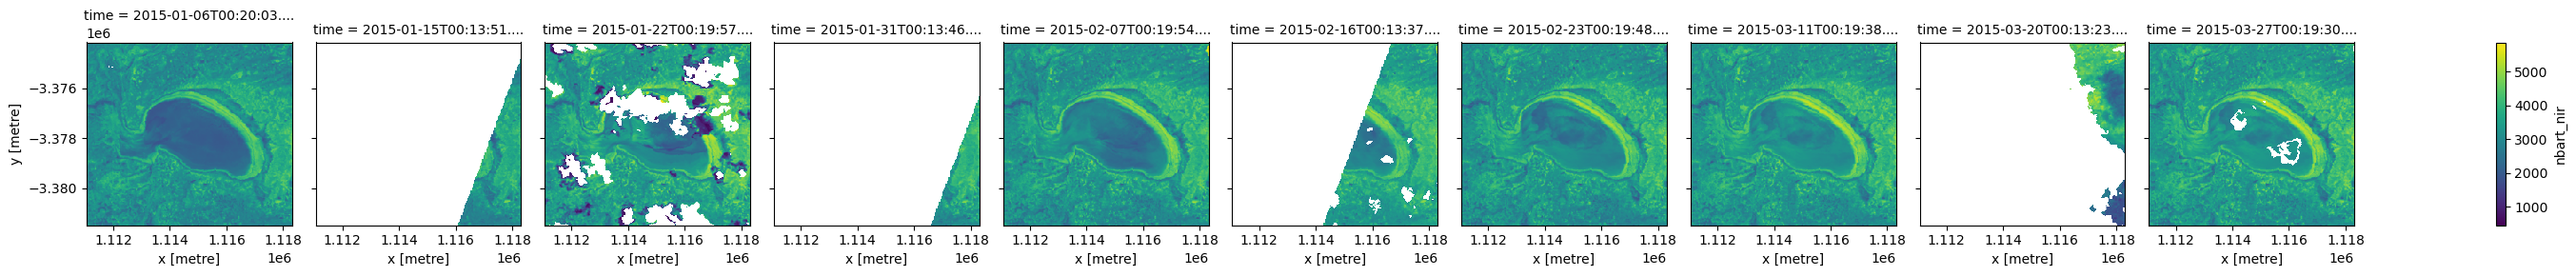

In [120]:
ds.nbart_nir.isel(time=slice(0,10)).plot(col="time")

## Working with time
### Indexing by time
We can select data for an entire year by passing a string to `.sel()`:

In [129]:
ds.sel(time='2015')

<xarray.Dataset> Size: 21MB
Dimensions:      (time: 44, y: 244, x: 242)
Coordinates:
  * y            (y) float64 2kB -3.374e+06 -3.374e+06 ... -3.381e+06 -3.381e+06
  * x            (x) float64 2kB 1.111e+06 1.111e+06 ... 1.118e+06 1.118e+06
    spatial_ref  int32 4B 3577
  * time         (time) datetime64[ns] 352B 2015-01-06T00:20:03.050919 ... 20...
Data variables:
    nbart_nir    (time, y, x) float32 10MB 2.844e+03 2.895e+03 ... 2.845e+03
    oa_fmask     (time, y, x) float32 10MB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0

Or select a single month:

In [130]:
ds.sel(time='2015-05')

<xarray.Dataset> Size: 2MB
Dimensions:      (time: 4, y: 244, x: 242)
Coordinates:
  * y            (y) float64 2kB -3.374e+06 -3.374e+06 ... -3.381e+06 -3.381e+06
  * x            (x) float64 2kB 1.111e+06 1.111e+06 ... 1.118e+06 1.118e+06
    spatial_ref  int32 4B 3577
  * time         (time) datetime64[ns] 32B 2015-05-07T00:12:56.232841 ... 201...
Data variables:
    nbart_nir    (time, y, x) float32 945kB nan nan nan nan ... nan nan nan nan
    oa_fmask     (time, y, x) float32 945kB nan nan nan nan ... nan nan nan nan

Or select a range of dates using `slice()`. This selects all observations between the two dates, inclusive of both the start and stop values:

In [131]:
ds.sel(time=slice('2015-06', '2016-01'))

<xarray.Dataset> Size: 14MB
Dimensions:      (time: 30, y: 244, x: 242)
Coordinates:
  * y            (y) float64 2kB -3.374e+06 -3.374e+06 ... -3.381e+06 -3.381e+06
  * x            (x) float64 2kB 1.111e+06 1.111e+06 ... 1.118e+06 1.118e+06
    spatial_ref  int32 4B 3577
  * time         (time) datetime64[ns] 240B 2015-06-08T00:13:02.348676 ... 20...
Data variables:
    nbart_nir    (time, y, x) float32 7MB nan nan nan ... 2.913e+03 2.978e+03
    oa_fmask     (time, y, x) float32 7MB nan nan nan nan ... 1.0 1.0 1.0 1.0

### Using the datetime accessor
`xarray` allows you to easily extract additional information from the `time` dimension in Digital Earth Australia data. For example, we can get a list of what season each observation belongs to:

In [132]:
ds.time.dt.season

<xarray.DataArray 'season' (time: 90)> Size: 1kB
array(['DJF', 'DJF', 'DJF', 'DJF', 'DJF', 'DJF', 'DJF', 'MAM', 'MAM',
       'MAM', 'MAM', 'MAM', 'MAM', 'MAM', 'MAM', 'MAM', 'MAM', 'MAM',
       'JJA', 'JJA', 'JJA', 'JJA', 'JJA', 'JJA', 'JJA', 'JJA', 'JJA',
       'JJA', 'JJA', 'SON', 'SON', 'SON', 'SON', 'SON', 'SON', 'SON',
       'SON', 'SON', 'SON', 'SON', 'DJF', 'DJF', 'DJF', 'DJF', 'DJF',
       'DJF', 'DJF', 'DJF', 'DJF', 'DJF', 'DJF', 'DJF', 'MAM', 'MAM',
       'MAM', 'MAM', 'MAM', 'MAM', 'MAM', 'MAM', 'MAM', 'MAM', 'MAM',
       'JJA', 'JJA', 'JJA', 'JJA', 'JJA', 'JJA', 'JJA', 'JJA', 'JJA',
       'JJA', 'JJA', 'JJA', 'SON', 'SON', 'SON', 'SON', 'SON', 'SON',
       'SON', 'SON', 'SON', 'SON', 'SON', 'DJF', 'DJF', 'DJF', 'DJF'],
      dtype='<U3')
Coordinates:
    spatial_ref  int32 4B 3577
  * time         (time) datetime64[ns] 720B 2015-01-06T00:20:03.050919 ... 20...

Or the day of the year:

In [133]:
ds.time.dt.dayofyear

<xarray.DataArray 'dayofyear' (time: 90)> Size: 720B
array([  6,  15,  22,  31,  38,  47,  54,  70,  79,  86,  95, 102, 111,
       118, 127, 134, 143, 150, 159, 166, 175, 182, 191, 198, 207, 214,
       223, 230, 239, 246, 255, 262, 271, 278, 287, 294, 303, 310, 319,
       326, 335, 342, 351, 358,   2,   9,  18,  25,  34,  41,  50,  57,
        66,  73,  82,  89,  98, 105, 114, 121, 130, 137, 146, 153, 162,
       169, 178, 185, 194, 201, 210, 217, 226, 233, 242, 249, 258, 265,
       274, 281, 290, 297, 306, 313, 322, 329, 338, 345, 354, 361])
Coordinates:
    spatial_ref  int32 4B 3577
  * time         (time) datetime64[ns] 720B 2015-01-06T00:20:03.050919 ... 20...

### Grouping and resampling by time
`xarray` also provides some shortcuts for aggregating data over time. In the example below, we first group our data by season, then take the median of each group. This produces a new dataset with only four observations (one per season). 

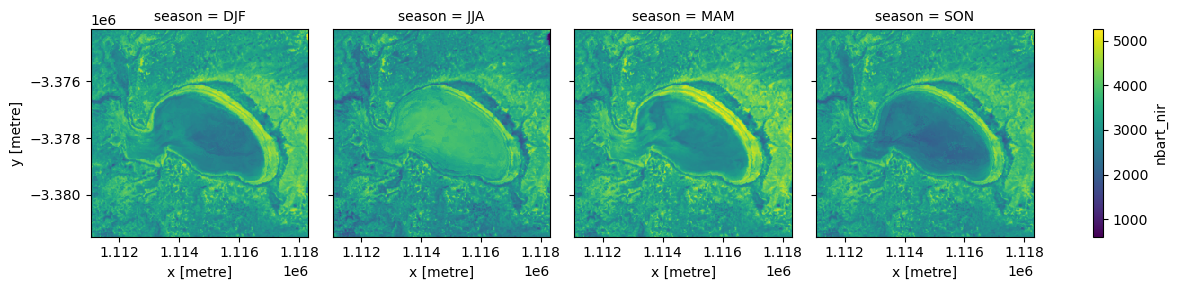

In [134]:
# Group the time series into seasons, and take median of each time period
ds_seasonal = ds.groupby('time.season').median(dim='time')

# Plot the output
ds_seasonal.nbart_nir.plot(col='season', col_wrap=4)
plt.show()

We can also use the `.resample()` method to summarise our dataset into larger chunks of time. In the example below, we produce a median composite for every 6 months of data in our dataset:

/env/lib/python3.10/site-packages/xarray/groupers.py:513: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


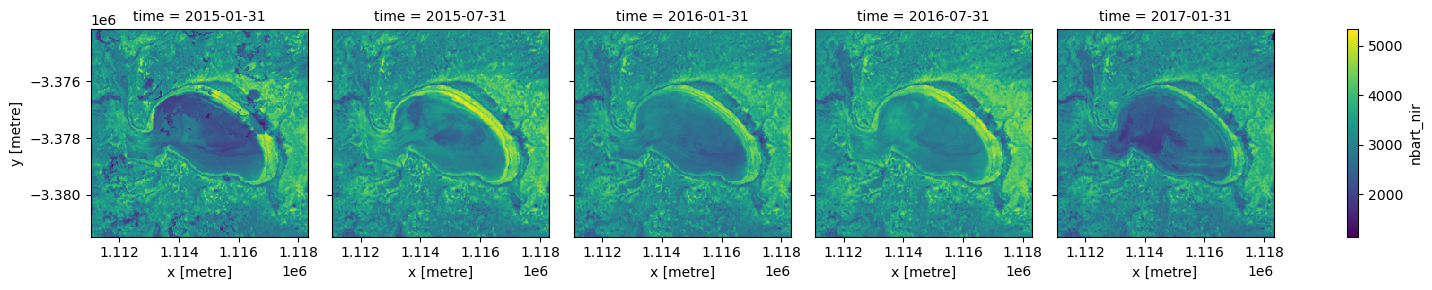

In [135]:
# Resample to combine each 6 months of data into a median composite
ds_resampled = ds.resample(time='6m').median()

# Plot the new resampled data
ds_resampled.nbart_nir.plot(col='time')
plt.show()

### Interpolating new timesteps
Sometimes, we want to return data for specific times/dates that weren't observed by a satellite. 
To estimate what the landscape appeared like on certain dates, we can use the `.interp()` method to interpolate between the nearest two observations.

By default, the `interp()` method uses linear interpolation (`method='linear'`). Another useful option is `method='nearest'`, which will return the nearest satellite observation to the specified date(s).

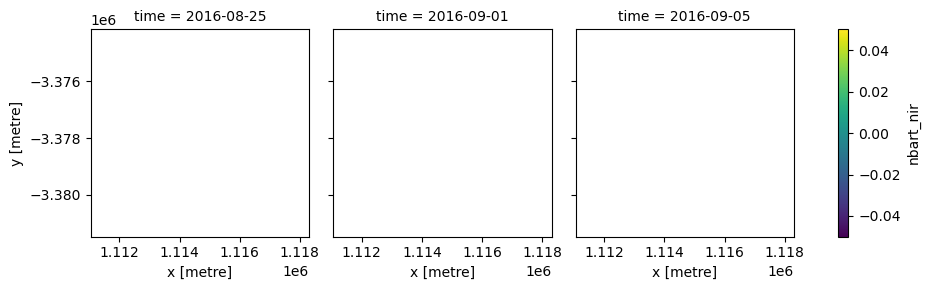

In [136]:
# New dates to interpolate data for
new_dates = ['2016-08-25', '2016-09-01', '2016-09-05']

# Interpolate Landsat values for three new dates
ds_interp = ds.interp(time=new_dates)

# Plot the new interpolated data
ds_interp.nbart_nir.plot(col='time')
plt.show()


***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last tested:**


In [47]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2025-12-11'